# Spillover Risk Heatmap

This notebook generates the risk visualizations for the poster.

We combine two things to estimate spillover risk:
- **How many viral sequences** come from a host/region (volume = more surveillance = more known risk)
- **Phylogenetic risk score** (how closely related the host is to humans)

The heatmap shows which host group + continent combinations have the highest combined risk.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import altair as alt
from vega_datasets import data as vega_data
import os

# if you get an import error, run in terminal:
# pip install altair vega_datasets

In [15]:
df = pd.read_csv('../data/processed/features.csv', low_memory=False)
print(f'Rows: {df.shape[0]:,}')
df.head()

Rows: 3,256,603


,Accession,Host,host_group,divergence_mya,phylo_risk_score,Molecule_type,molecule_type_code,Continent,continent_code,Geo_Location,Length,is_complete,Year,Month
0,NC_138438,Ailurus fulgens,other,150.0,0.049787,ssDNA,1,Asia,1,China: Sichuan Province,2820,1,2020,5
1,NC_138461,Ailurus fulgens,other,150.0,0.049787,ssDNA,1,Asia,1,China: Sichuan Province,2497,1,2015,3
2,NC_097195,Pteropus tonganus,bat,95.0,0.149569,ssDNA,1,Oceania,6,Tonga,2214,1,2014,6
3,NC_099061,Chiroptera,bat,95.0,0.149569,ssDNA,1,South America,4,Brazil,1728,1,2012,2
4,NC_116632,Orcinus orca,other,150.0,0.049787,ssDNA,1,North America,3,Saint Vincent and the Grenadines,1939,1,2015,8


## Heatmap: Spillover Risk by Host Group × Continent

Each cell = average phylogenetic risk score for that host + region combination, weighted by number of sequences.

Darker = higher spillover risk.

In [19]:
# --- Extract country from Geo_Location (format is "Country: Region" or just "Country") ---
df['country'] = df['Geo_Location'].dropna().str.split(':').str[0].str.strip()

# --- Aggregate risk by country ---
country_risk = (
    df[df['country'].notna() & ~df['host_group'].isin(['unknown', 'human'])]
    .groupby('country')
    .agg(
        mean_risk=('phylo_risk_score', 'mean'),
        sequence_count=('Accession', 'count'),
    )
    .reset_index()
)

# --- Map country names to ISO numeric codes for joining with Vega world map ---
COUNTRY_ISO = {
    'Afghanistan': 4, 'Albania': 8, 'Algeria': 12, 'Angola': 24, 'Argentina': 32,
    'Armenia': 51, 'Australia': 36, 'Austria': 40, 'Azerbaijan': 31, 'Bangladesh': 50,
    'Belgium': 56, 'Benin': 204, 'Bolivia': 68, 'Brazil': 76, 'Bulgaria': 100,
    'Burkina Faso': 854, 'Burundi': 108, 'Cambodia': 116, 'Cameroon': 120,
    'Canada': 124, 'Central African Republic': 140, 'Chile': 152, 'China': 156,
    'Colombia': 170, 'Congo': 178, 'Democratic Republic of the Congo': 180,
    'Costa Rica': 188, 'Croatia': 191, 'Cuba': 192, 'Czech Republic': 203,
    'Denmark': 208, 'Ecuador': 218, 'Egypt': 818, 'El Salvador': 222,
    'Ethiopia': 231, 'Finland': 246, 'France': 250, 'Gabon': 266, 'Germany': 276,
    'Ghana': 288, 'Greece': 300, 'Guatemala': 320, 'Guinea': 324, 'Honduras': 340,
    'Hungary': 348, 'India': 356, 'Indonesia': 360, 'Iran': 364, 'Iraq': 368,
    'Israel': 376, 'Italy': 380, 'Ivory Coast': 384, 'Jamaica': 388, 'Japan': 392,
    'Jordan': 400, 'Kazakhstan': 398, 'Kenya': 404, 'Laos': 418, 'Lebanon': 422,
    'Liberia': 430, 'Libya': 434, 'Madagascar': 450, 'Malawi': 454, 'Malaysia': 458,
    'Mali': 466, 'Mexico': 484, 'Mongolia': 496, 'Morocco': 504, 'Mozambique': 508,
    'Myanmar': 104, 'Nepal': 524, 'Netherlands': 528, 'New Zealand': 554,
    'Nicaragua': 558, 'Nigeria': 566, 'Norway': 578, 'Pakistan': 586, 'Panama': 591,
    'Paraguay': 600, 'Peru': 604, 'Philippines': 608, 'Poland': 616, 'Portugal': 620,
    'Romania': 642, 'Russia': 643, 'Rwanda': 646, 'Saudi Arabia': 682, 'Senegal': 686,
    'Sierra Leone': 694, 'Singapore': 702, 'South Africa': 710, 'South Korea': 410,
    'Spain': 724, 'Sri Lanka': 144, 'Sudan': 729, 'Sweden': 752, 'Switzerland': 756,
    'Taiwan': 158, 'Tanzania': 834, 'Thailand': 764, 'Tonga': 776,
    'Trinidad and Tobago': 780, 'Turkey': 792, 'Uganda': 800, 'Ukraine': 804,
    'United Kingdom': 826, 'USA': 840, 'United States': 840, 'Uruguay': 858,
    'Uzbekistan': 860, 'Venezuela': 862, 'Vietnam': 704, 'Yemen': 887,
    'Zambia': 894, 'Zimbabwe': 716,
}

country_risk['id'] = country_risk['country'].map(COUNTRY_ISO)
country_risk = country_risk.dropna(subset=['id'])
country_risk['id'] = country_risk['id'].astype(int)

# --- Build the Vega-Altair global map ---
world = alt.topo_feature(vega_data.world_110m.url, 'countries')

background = alt.Chart(world).mark_geoshape(fill='#e8e8e8', stroke='white', strokeWidth=0.5)

choropleth = (
    alt.Chart(world)
    .mark_geoshape(stroke='white', strokeWidth=0.4)
    .transform_lookup(
        lookup='id',
        from_=alt.LookupData(country_risk, 'id', ['mean_risk', 'sequence_count', 'country'])
    )
    .encode(
        color=alt.condition(
            'datum.mean_risk != null',
            alt.Color('mean_risk:Q',
                      scale=alt.Scale(scheme='orangered', domain=[0, 0.5]),
                      legend=alt.Legend(title='Phylogenetic Risk Score')),
            alt.value('#e8e8e8')
        ),
        tooltip=[
            alt.Tooltip('country:N', title='Country'),
            alt.Tooltip('mean_risk:Q', title='Avg Risk Score', format='.3f'),
            alt.Tooltip('sequence_count:Q', title='Sequences', format=','),
        ]
    )
)

global_map = (
    (background + choropleth)
    .project('naturalEarth1')
    .properties(width=800, height=450, title='Global Spillover Risk by Country')
    .configure_title(fontSize=16, fontWeight='bold')
    .configure_view(strokeWidth=0)
)

os.makedirs('../results', exist_ok=True)
global_map.save('../results/global_risk_map.html')
print('Saved interactive map to results/global_risk_map.html')
global_map.save('../results/global_risk_map.png', scale_factor=2)
global_map

Saved interactive map to results/global_risk_map.html


alt.LayerChart(...)

## Top High-Risk Host Species

Which individual host species appear most often **and** have the highest phylogenetic risk score? These are the biggest spillover concerns in the dataset.

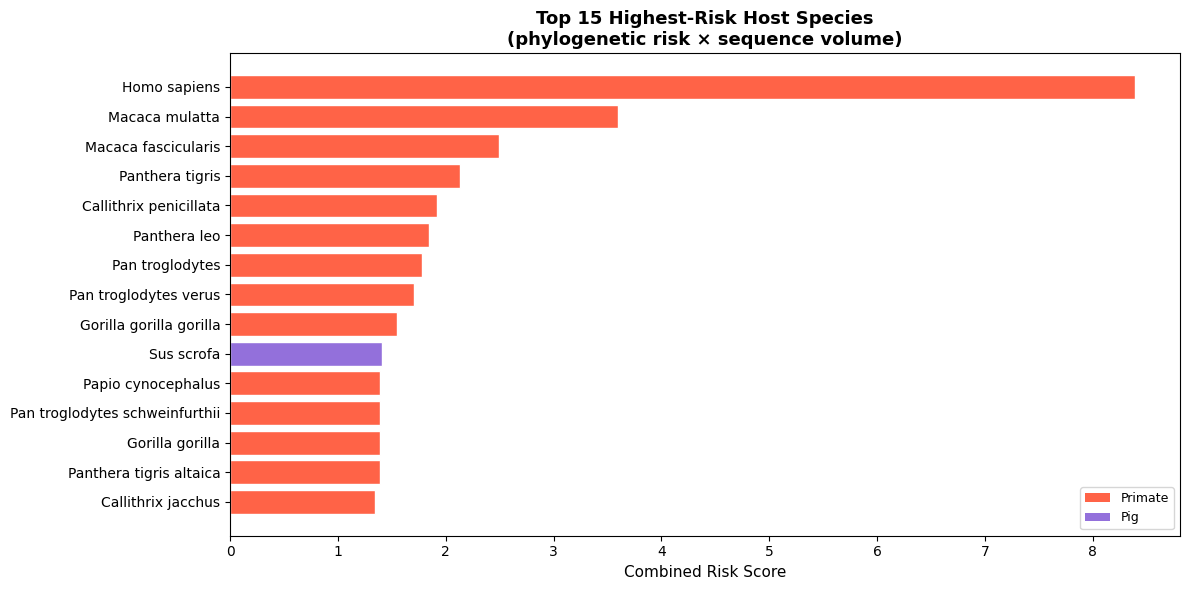

Saved to results/top_risk_hosts.png


In [17]:
# score = phylo_risk_score × log(sequence count) — balances risk with data volume
host_summary = (
    df[df['Host'].notna() & ~df['host_group'].isin(['unknown', 'human'])]
    .groupby('Host')
    .agg(
        count=('Accession', 'count'),
        phylo_risk=('phylo_risk_score', 'mean'),
        host_group=('host_group', 'first'),
    )
    .reset_index()
)

host_summary['combined_score'] = host_summary['phylo_risk'] * np.log1p(host_summary['count'])
top_hosts = host_summary.sort_values('combined_score', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'primate': 'tomato', 'bat': 'steelblue', 'rodent': 'goldenrod',
    'carnivore': 'mediumseagreen', 'pig': 'mediumpurple', 'pangolin': 'darkorange',
    'bird': 'cornflowerblue', 'cattle': 'peru', 'other': 'gray'
}
bar_colors = [colors.get(g, 'gray') for g in top_hosts['host_group']]

bars = ax.barh(top_hosts['Host'], top_hosts['combined_score'], color=bar_colors, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Highest-Risk Host Species\n(phylogenetic risk × sequence volume)', fontsize=13, fontweight='bold')
ax.set_xlabel('Combined Risk Score', fontsize=11)

# legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g.capitalize()) for g, c in colors.items() if g in top_hosts['host_group'].values]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../results/top_risk_hosts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/top_risk_hosts.png')

## Phylogenetic Risk Score vs Peak Infections

This is the core result — it directly shows that higher phylogenetic risk (host closer to humans) leads to larger outbreaks.

Each dot = one simulated spillover event. The trend line shows the relationship.

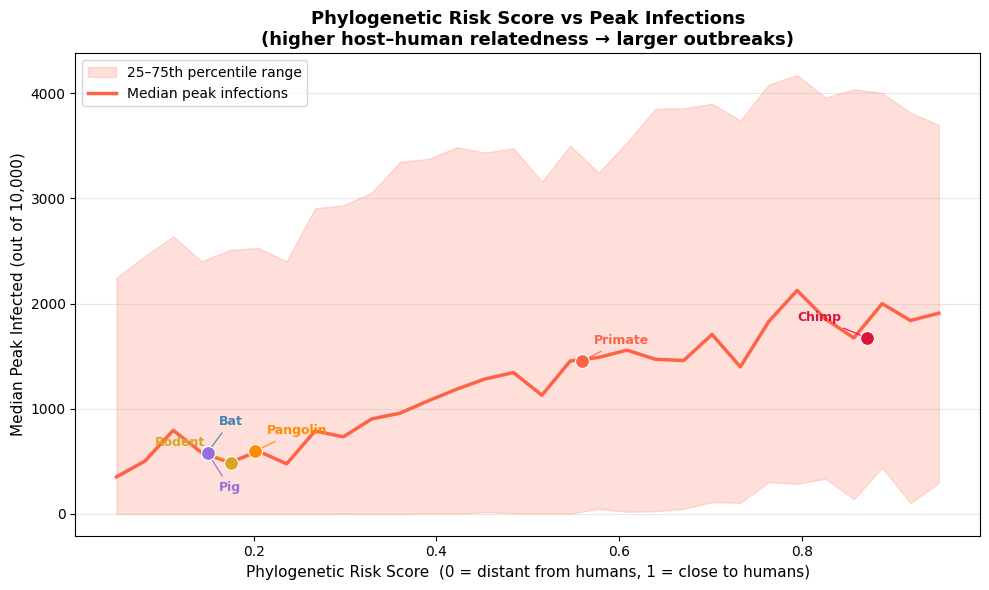

Saved to results/risk_vs_peak_infections.png


In [18]:
import sys
sys.path.insert(0, '..')

risk_scores = np.linspace(0.05, 0.95, 30)
N_SIMS = 500
T = 160
I0 = 1
N = 10_000
GAMMA_SHAPE, GAMMA_SCALE = 2.0, 0.10
SIGMA_SHAPE, SIGMA_SCALE = 2.0, 0.20

def run_seir(beta, gamma, sigma, N, I0, T):
    S, E, I, R = np.empty(T+1), np.empty(T+1), np.empty(T+1), np.empty(T+1)
    S[0], E[0], I[0], R[0] = N - I0, 0.0, I0, 0.0
    for t in range(T):
        new_exposed    = min(beta  * S[t] * I[t] / N, S[t])
        new_infectious = min(sigma * E[t], E[t])
        new_recovered  = min(gamma * I[t], I[t])
        S[t+1] = S[t] - new_exposed
        E[t+1] = E[t] + new_exposed    - new_infectious
        I[t+1] = I[t] + new_infectious - new_recovered
        R[t+1] = R[t] + new_recovered
    return np.column_stack([S, E, I, R])

rng = np.random.default_rng(42)
results = []

for risk in risk_scores:
    beta_mean  = 0.3 + 0.4 * risk
    beta_scale = beta_mean / 2.0
    betas  = rng.gamma(2.0,         beta_scale,  N_SIMS)
    gammas = rng.gamma(GAMMA_SHAPE, GAMMA_SCALE, N_SIMS)
    sigmas = rng.gamma(SIGMA_SHAPE, SIGMA_SCALE, N_SIMS)
    runs = np.stack([run_seir(b, g, s, N, I0, T) for b, g, s in zip(betas, gammas, sigmas)])
    peak_I = runs[:, :, 2].max(axis=1)
    results.append({
        'risk_score':  risk,
        'median_peak': np.median(peak_I),
        'lower':       np.percentile(peak_I, 25),
        'upper':       np.percentile(peak_I, 75),
    })

scatter_df = pd.DataFrame(results)

# custom offsets per label so nothing overlaps
host_points = pd.DataFrame([
    {'host': 'Bat',      'risk': np.exp(-95  / 50), 'color': 'steelblue',   'dx':  8, 'dy':  20},
    {'host': 'Pig',      'risk': np.exp(-95  / 50), 'color': 'mediumpurple','dx':  8, 'dy': -28},
    {'host': 'Rodent',   'risk': np.exp(-87  / 50), 'color': 'goldenrod',   'dx': -55,'dy':  12},
    {'host': 'Pangolin', 'risk': np.exp(-80  / 50), 'color': 'darkorange',  'dx':  8, 'dy':  12},
    {'host': 'Primate',  'risk': np.exp(-29  / 50), 'color': 'tomato',      'dx':  8, 'dy':  12},
    {'host': 'Chimp',    'risk': np.exp(-6.9 / 50), 'color': 'crimson',     'dx': -50,'dy':  12},
])
host_points['median_peak'] = host_points['risk'].apply(
    lambda r: scatter_df.iloc[(scatter_df['risk_score'] - r).abs().argsort().iloc[0]]['median_peak']
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(scatter_df['risk_score'], scatter_df['lower'], scatter_df['upper'],
                alpha=0.2, color='tomato', label='25–75th percentile range')
ax.plot(scatter_df['risk_score'], scatter_df['median_peak'],
        color='tomato', lw=2.5, label='Median peak infections')

for _, row in host_points.iterrows():
    ax.scatter(row['risk'], row['median_peak'], color=row['color'],
               s=100, zorder=5, edgecolors='white', linewidths=0.8)
    ax.annotate(row['host'],
                xy=(row['risk'], row['median_peak']),
                xytext=(row['dx'], row['dy']), textcoords='offset points',
                fontsize=9, color=row['color'], fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=row['color'], lw=0.8))

ax.set_title('Phylogenetic Risk Score vs Peak Infections\n(higher host–human relatedness → larger outbreaks)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Phylogenetic Risk Score  (0 = distant from humans, 1 = close to humans)', fontsize=11)
ax.set_ylabel('Median Peak Infected (out of 10,000)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/risk_vs_peak_infections.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/risk_vs_peak_infections.png')